## SAM EVAL

### BOX MODE

In [6]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2
import numpy as np
import json
import os
from matplotlib import pyplot as plt
from pycocotools import mask as maskUtils

sam2_checkpoint = "sam2_logs/configs/sam2.1_training/sam2.1_hiera_l_OBIMD_stage2/checkpoints/checkpoint.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device='cuda:1')

predictor = SAM2ImagePredictor(sam2_model)

In [7]:
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))  
    
def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [8]:
miou = []
for img_path in sorted(os.listdir('data/OBIMD_test100/JPEGImages')):
    image = cv2.imread(os.path.join('data/OBIMD_test100/JPEGImages', img_path))
    base_name = os.path.splitext(img_path)[0]
    with open(os.path.join('data/OBIMD_test100/facsimile_json', f'{base_name}.json')) as f:
        data = json.load(f)
    predictor.set_image(image)
    input_box = []
    gt_masks = []
    for d in data['annotations']:
        input_box.append(d['bbox'])
        binary_mask = maskUtils.decode(d['segmentation'])
        gt_masks.append(binary_mask)
    input_box = np.array(input_box).reshape(-1, 4)
    input_box[:, 2:] += input_box[:, :2]  # Convert from [x, y, w, h] to [x0, y0, x1, y1]
    masks, scores, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box[None, :],
        multimask_output=False,
    )
    for box, mask, gt_mask in zip(input_box, masks, gt_masks):
        x0, y0, x1, y1 = box
        pred = mask[0, y0:y1, x0:x1]
        gt = gt_mask[y0:y1, x0:x1] > 0
        if np.sum(gt) == 0:
            continue
        miou.append(np.sum(pred * gt) / (np.sum(pred) + np.sum(gt) - np.sum(pred * gt)))    
print(np.mean(miou))

0.696743765210838


## ALIGN MODE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import json
from pycocotools import mask as maskUtils
from tqdm import tqdm
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "sam2_logs/configs/sam2.1_training/sam2.1_hiera_l_OBIMD_stage2/checkpoints/checkpoint.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device='cuda:3')

In [2]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

In [ ]:
miou = []
video_dir = 'data/OBIMD_test100/rubbing_sav/'
for img_path in tqdm(sorted(os.listdir('data/OBIMD_test100/JPEGImages'))):
    inference_state = predictor.init_state(video_path=os.path.join(video_dir, img_path.split('.')[0]))
    predictor.reset_state(inference_state)
    facsimile = cv2.imread(f'data/OBIMD_raw_hj/facsimile/{img_path}', cv2.IMREAD_GRAYSCALE)
    with open(os.path.join('data/OBIMD_test100/facsimile_json', img_path.replace('jpg', 'json'))) as f:
        data = json.load(f)
    gt_masks = []
    input_box = []
    for i, d in enumerate(data['annotations']):
        binary_mask = maskUtils.decode(d['segmentation'])
        gt_masks.append(binary_mask)
        # Add misalign facs to first frame as mask
        frame_idx, obj_ids, video_res_masks = predictor.add_new_mask(
            inference_state=inference_state,
            frame_idx=0,
            obj_id=i,
            mask=facsimile,
        )
    for i, d in enumerate(data['annotations']):
        box = np.array(d['bbox']).reshape(-1, 4)
        box[:, 2:] += box[:, :2]  # Convert from [x, y, w, h] to [x0, y0, x1, y1]
        # Add box to the second frame
        _, _, out_mask_logits = predictor.add_new_points_or_box(
            inference_state=inference_state,
            frame_idx=1,
            obj_id=i,
            box= box[None, :],
        )
        input_box.append(box[0])
    
    for box, mask, gt_mask in zip(input_box, out_mask_logits.cpu().numpy() > 0, gt_masks):
        x0, y0, x1, y1 = box
        pred = mask[0, y0:y1, x0:x1]
        gt = gt_mask[y0:y1, x0:x1] > 0
        if np.sum(gt) == 0:
            continue
        miou.append(np.sum(pred * gt) / (np.sum(pred) + np.sum(gt) - np.sum(pred * gt)))
    break
print(np.mean(miou))

## 数据飞轮数据split

In [ ]:
import os
import re
difference = []
file = set([int(f.split('.')[0][1:]) for f in os.listdir('data/OBIMD_raw/OBIMD_rubbing') if f.startswith('h') and not f.startswith('hd')])
for unsuper_data in os.listdir("/data/huxingjian/historical_document/YQWY/HJ"):
    try:
        image_id = int(unsuper_data.split('.')[0][1:])
        if image_id not in file:
            difference.append(unsuper_data)
    except:
        # 可能是“合xxx正”这种
        image_id = int(re.findall(r'\d+', unsuper_data)[0])
        if image_id not in file:
            difference.append(unsuper_data)
        else:
            print(f"File {unsuper_data} exists in the dataset.")


## 花东数据处理

((array([ 171.,  181.,  364.,  693., 1275., 2431., 3790., 5509., 7445.,
         8790., 9428., 8766., 6659., 4065., 1687.,  503.,  135.,   30.,
           13.,   12.]),
  array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
         0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
  <BarContainer object of 20 artists>),
 13104,
 61947)

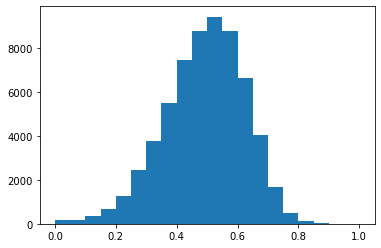

In [4]:
# 过一遍iou的分布，看看大于0.5的有多少
import os
import json
import matplotlib.pyplot as plt
import numpy as np
ious = []
for file in os.listdir('data/OBIMD_stage1/facsimile_json_new'):
    with open(os.path.join('data/OBIMD_stage1/facsimile_json_new', file)) as f:
        data = json.load(f)
    ious.extend([annotation['predicted_iou'] for annotation in data['annotations']])
    filter_annotions = dict(image_info=data['image_info'], annotations=[])
    filter_annotions['annotations'] = [annotation for annotation in data['annotations'] if annotation['predicted_iou'] > 0.6]
    if len(filter_annotions['annotations']) == 0:
        continue
    with open(os.path.join('data/OBIMD_stage1/facsimile_json_iou0.6', file), 'w') as f:
        json.dump(filter_annotions, f, indent=2)
ious = np.array(ious)
plt.hist(ious, bins=20), len(ious[ious>0.6]), len(ious)

In [5]:
with open("data/OBIMD_raw_hj/train.txt") as f:
    train = set([l.strip() for l in f.readlines()])
with open("data/OBIMD_stage1/train.txt", 'w') as f:
    for file in os.listdir("data/OBIMD_stage1/facsimile_json_iou0.6"):
        if file.split('.')[0] in train:
            f.write(file.split('.')[0] + '\n')